In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

import shap

/home/matheus/Dev/projeto_fraude/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/clean_train.csv')

In [3]:
ids = df.pop('Customer_ID')
X, y = df.drop("Credit_Score", axis=1), df["Credit_Score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)

In [5]:
PARAM_GRID_XG = {
    'n_estimators': [500, 700],
    'max_depth': [6, 9],
    'learning_rate': [0.05],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [5, 10],
    'subsample': [0.7, 0.9],
}

xgboost = xgb.XGBClassifier(
        random_state=4,
        num_class=3,
        objective='multi:softprob',
        eval_metric='mlogloss'
    )

model = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=PARAM_GRID_XG,
    scoring='f1_macro',
    verbose=0,
    cv = StratifiedKFold(n_splits=5),
    random_state=4,
    n_jobs=-1
)

In [6]:
model.fit(X_train, y_train, verbose=False)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05], 'max_depth': [6, 9], 'min_child_weight': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",4
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` inst

In [8]:
explainer = shap.Explainer(model.best_estimator_)
shap_values = explainer(X_test)

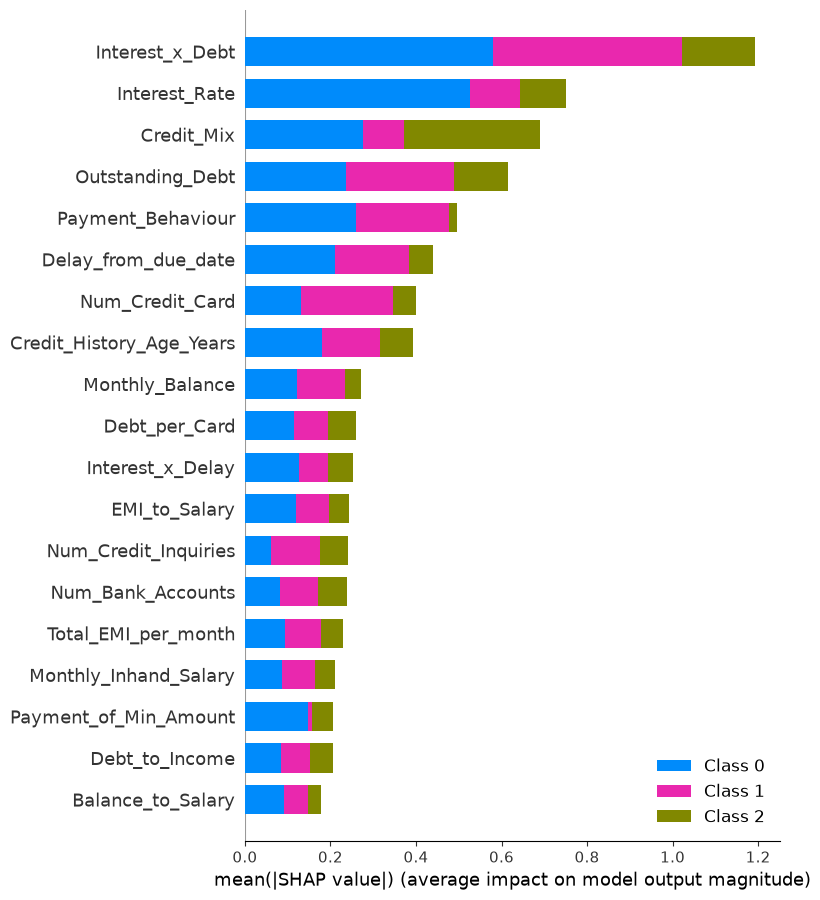

In [9]:
shap.summary_plot(shap_values, X_test)

In [14]:
entrada = X.iloc[4: 5]
model.predict_proba(entrada)

array([[0.7933417 , 0.03839005, 0.16826823]], dtype=float32)

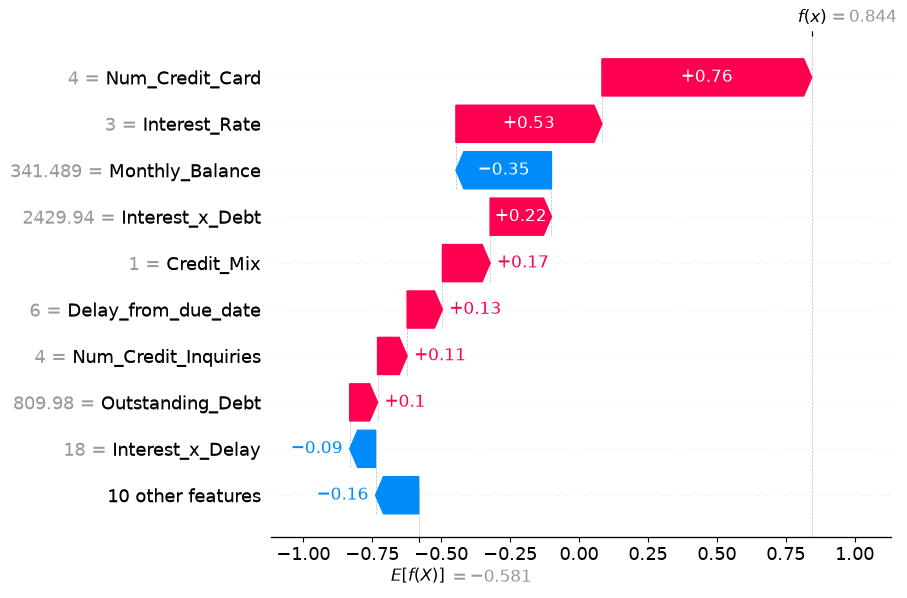

In [23]:
shap.initjs()
explainer_entrada = shap.Explanation(
    values=shap_values[4].values[:, 0],
    base_values=explainer.expected_value[0],
    data=entrada.values[0],
    feature_names=X_test.columns
)

shap.plots.waterfall(explainer_entrada)

In [36]:
values = explainer_entrada.values
features = explainer_entrada.feature_names

idx = np.argsort(np.abs(values))[::-1][:5] # Indice das classes mais relevantes na predicao
most_relevant_features = [features[i] for i in idx]

In [37]:
most_relevant_features

['Num_Credit_Card',
 'Interest_Rate',
 'Monthly_Balance',
 'Interest_x_Debt',
 'Credit_Mix']